# Generating and Visualizing Stationary Spike Trains with the Neo Package

<a target="_blank" href="https://colab.research.google.com/github/ANDA-NI-2026/ANDA-Day1-Spike-Train-Correlations/blob/main/01_homework/01_hw_stationary_spiketrains.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In this notebook, we will get started with a few core ideas and tools for working with neuronal spike trains in Python. We will generate simple synthetic spike trains, visualize them, count spikes, and compare what we observe to what we would expect from a basic statistical model. 

Our goal with this notebook is not to build a biologically complete model yet, but to develop intuition for how spike times behave as data: they are structured, measurable, and statistically meaningful, but also variable from trial to trial. Besides the standard Python scientific packages like [Matplotlib](https://matplotlib.org/stable/api/pyplot_summary.html) and [Numpy](https://numpy.org/doc/stable/user/index.html), we will also introduce neuroscience-focused packages like [Neo](https://neo.readthedocs.io/en/latest/), [Elephant](https://elephant.readthedocs.io/en/latest/), and [Quantities](https://python-quantities.readthedocs.io/en/latest/), which we will use extensively throughout the course.

## Setup

### Import Packages

In [10]:
from elephant.spike_train_generation import StationaryPoissonProcess
import matplotlib.pyplot as plt
from neo.core import SpikeTrain
import numpy as np
import quantities as pq

### Utility Functions

These are some helper functions we'll use in the exercises.  Please run the cell to get the functions:

In [3]:
from numpy.typing import NDArray

class utils:

    @staticmethod
    def generate_spiketrain(rate: float, t_stop: float) -> NDArray:
        neuron = StationaryPoissonProcess(rate=rate*pq.Hz, t_stop=t_stop*pq.s)
        st = neuron.generate_spiketrain()
        st_times = st.times
        return st_times
    
    @staticmethod
    def plot_poisson_distribution(mu: float) -> None:
        import numpy as np
        from scipy.stats import poisson, expon
        from scipy.interpolate import interp1d
        
        low = int(poisson.ppf(.001, mu))
        high = int(poisson.ppf(.999, mu))
        
        x = np.arange(low, high + 1, dtype=int)
        prob = poisson.pmf(k=x, mu=mu)
        
        plt.plot(x, prob, color="black")
        


## Section 1: Generating and Visualizing Single Spiketrains

In this first section, you will generate individual spike trains from a stationary Poisson process. This is a simple model where spikes occur randomly over time, but with a constant average firing rate. For example, a neuron firing at 5 Hz is expected to produce about 5 spikes per second on average, but that does not mean the spikes will be evenly spaced or that every simulation will produce exactly the same number of spikes. The exercises here are meant to help you connect the firing rate, the observation time, the number of spikes you expect, and the spike times you actually observe.

### Code Reference



| Code                                                    | Description                                                                                  |
| ------------------------------------------------------- | -------------------------------------------------------------------------------------------- |
| **`st = utils.generate_spiketrain(rate=5, t_stop=10)`** | Generate one spike train from a neuron firing at an average rate of `5 Hz` for `10 seconds`. |
| **`len(st)`**                                           | Count the number of spikes in the generated spike train.                                     |
| **`expected = rate * t_stop`**                          | Compute the expected number of spikes from firing rate and recording duration.               |
| **`plt.eventplot(st)`**                                 | Make a simple raster plot showing each spike time as an event.                               |
| **`plt.eventplot(st, colors="black")`**                 | Plot spike times using black event markers.                                                  |
| **`plt.eventplot(st, linewidths=0.5)`**                 | Make event lines thinner to reduce over-plotting.                                            |
| **`plt.eventplot(st, alpha=0.5)`**                      | Make event lines partly transparent so dense regions are easier to see.                      |



### Exercises

Please fill in the blank cells with working code, according to each exercise below.  

*Note*: **"Example"** exercises already have the solutions, and will help show how the code is used for the exercises that follow.

**Example**: Generate a spikeetrain from a cell spiking an average rate of `5` times per second ("Hz") over a `1000`-second period, and count the number of spikes.  
  - How many spikes would you expect to see?
  - Is the measured amount close to your expectation?

In [12]:
st = utils.generate_spiketrain(rate=5, t_stop=1000)
len(st)

4972

**Exercise**: Generate a spiketrain from a cell spiking an average rate of `10` times per second ("Hz") over a `5`-second period, and count the number of spikes.  
  - How many spikes would you expect to see?
  - Is the measured amount close to your expectation?

**Exercise**: Generate a spiketrain from a cell spiking an average rate of `7` times per second ("Hz") over a `10`-second period, then use the `plt.eventplot()` function to make a rasterplot and view each spike in the spiketrain over time.  
  - Are the spikes evenly-spaced in time?
  - If you re-run the code, do the spikes always come at the same times?

**Exercise**: Generate a spiketrain from a cell spiking an average rate of `20` times per second ("Hz") over a `100`-second period, then use the `plt.eventplot()` function to make a rasterplot and view each spike in the spiketrain over time.  

Now, it's too difficult to see the spikes because of a problem called **"over-plotting"**! Fix the plot: add the following parameters to the `plt.eventplot()` function to make each event more visible:
  - `linewidths=0.5`: Makes the lines narrower (so less overlap)
  - `colors='black'`: Makes the lines darker (so stronger contrast with background)
  - `alpha=0.5`: Makes the lines translucent (so overlap increases contrast)

## Section 2: Using Multiple Spiketrains to Infer the Underlying Statistical Parameters

One spike train can be quite noisy, so it is hard to learn much from a single observation. In this section, we will generate many spike trains from the same underlying process and look at how the spike counts vary across repetitions. This is closer to the way we often reason about neural data: individual trials may differ, but repeated trials can reveal the statistical structure of the process that generated them. We will compare the simulated spike-count distribution to the distribution expected from a Poisson model, where the expected number of spikes is given by the firing rate multiplied by the recording duration.

### Code Reference


| Code                                                              | Description                                                               |
| ----------------------------------------------------------------- | ------------------------------------------------------------------------- |
| **`sts = [utils.generate_spiketrain(10, 5) for _ in range(20)]`** | Generate `20` spike trains with the same firing rate and duration.        |
| **`plt.eventplot(sts)`**                                          | Make a raster plot of multiple spike trains.                              |
| **`counts = [len(st) for st in sts]`**                            | Count the number of spikes in each spike train.                           |
| **`plt.hist(counts)`**                                            | Plot a histogram of spike counts.                                         |
| **`plt.hist(counts, density=True)`**                              | Plot spike-count frequencies as proportions rather than raw counts.       |
| **`mu = rate * t_stop`**                                          | Compute the expected average spike count for a Poisson model.             |
| **`utils.plot_poisson_distribution(mu=8)`**                       | Plot the Poisson distribution expected for an average spike count of `8`. |


### Exercises

**Example**: Generate `3` spike trains, each with an average firing rate of `6` Hz and a measurement duration of `9` seconds.  Then plot them as a raster plot.

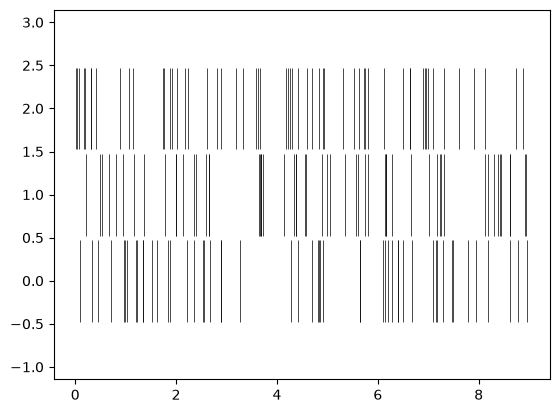

In [6]:
sts = [utils.generate_spiketrain(rate=6, t_stop=9) for _ in range(3)]
plt.eventplot(sts, linelengths=.95, linewidths=.5, colors='black');

**Exercise**: Generate `10` spike trains, each with an average firing rate of `4` Hz and a measurement duration of `15` seconds.  Then plot them as a raster plot.

**Example**:  For the following spike trains, use `np.mean()` to calculate the average number of spikes per spike train.

In [ ]:
sts = [utils.generate_spiketrain(10, 10) for _ in range(100)]

In [16]:
counts = [len(st) for st in sts]
np.mean(counts)

np.float64(100.91)

**Exercise**:  For the following spike trains, use `np.std()` to calculate the standard deviation of spikes observed between each spike train.

In [ ]:
sts = [utils.generate_spiketrain(10, 10) for _ in range(100)]

**Exercise**:  For the following spike trains, use `plt.hist()` to visualize the distribution of spike counts measured in each spike train.

In [18]:
sts = [utils.generate_spiketrain(10, 10) for _ in range(100)]

**Exercise**: Does the distribution of spike counts match what would be expected from a Poisson model?  For the spike counts calculated below:
  - Plot the proportional distribution of spike counts with `plt.hist(density=True)`.
  - Plot the expected distribution with `utils.plot_poisson_distribution()`.  This function needs a parameter called `mu`; this is the expected number of spikes (i.e. average spike rate, multiplied by time duration)
  - Does the shape of the expected distrubtion roughly follow the measured spike distribution?

In [20]:
sts = [utils.generate_spiketrain(4, 2) for _ in range(500)]
counts = [len(st) for st in sts]

## Section 3: Working with Neo

This section introduces Neo, a package that provides standardized data objects for electrophysiology. So far, we have mostly treated spike times as simple arrays or lists. That is fine for small examples, but real analysis often needs more context: when the recording started, when it stopped, what units the times are measured in, and how the data should be passed between tools. A Neo SpikeTrain object stores spike times together with this kind of metadata. In this section, you will create SpikeTrain objects manually, inspect their contents, plot their spike times, and then use Elephant to generate Neo-compatible spike trains automatically.

### Code Reference

| Code                                                                    | Description                                                                  |
| :---------------------------------------------------------------------- | ---------------------------------------------------------------------------- |
| **`st = SpikeTrain([0.2, 0.5] * pq.s, t_start=0*pq.s, t_stop=1*pq.s)`** | Create a Neo `SpikeTrain` object with spike times and recording boundaries.  |
| **`st.times`**                                                          | Access the spike times stored in a `SpikeTrain`.                             |
| **`st.t_start`**                                                        | Access the start time of the recording.                                      |
| **`st.t_stop`**                                                         | Access the stop time of the recording.                                       |
| **`plt.eventplot(st.times)`**                                           | Make a raster plot from the spike times inside a Neo `SpikeTrain`.           |
| **`process = StationaryPoissonProcess(rate=5*pq.Hz, t_stop=3*pq.s)`**   | Create a stationary Poisson spike-train generator.                           |
| **`st = process.generate_spiketrain()`**                                | Generate one Neo `SpikeTrain` from the process.                              |
| **`sts = process.generate_n_spiketrains(50)`**                          | Generate `50` Neo `SpikeTrain` objects from the same process.                |
| **`st_times = process.generate_n_spiketrains(50, as_array=True)`**      | Generate `50` spike trains as arrays of spike times, which are easy to plot. |


### Exercises

In [260]:
from neo.core import SpikeTrain
import quantities as pq

**Example**: Construct a Neo `SpikeTrain` object that describes the following spike train:
  - spike times were observed at `0.2, 0.5, 0.9, and 1.3` seconds
  - measurements started at `0 seconds` and ended at `2 seconds`

In [251]:
st = SpikeTrain(
    times=[.2, .5, .9, 1.3] * pq.s, 
    t_start=0 * pq.s, 
    t_stop=2 * pq.s
)
st

SpikeTrain containing 4 spikes; units s; datatype float64  time: 0.0 s to 2.0 s

**Exercise**: Construct a Neo `SpikeTrain` object that describes the following spike train:
  - spike times were observed at `0.2, 0.5, 0.9, and 1.3` seconds
  - measurements started at `0 seconds` and ended at `2 seconds`

**Example**: Take the following `SpikeTrain` object and display the `starting time` (e.g. `t_start`) contained inside it.

In [ ]:
st = SpikeTrain(times=[.2, .5, .9, 1.3] * pq.s, t_start=0 * pq.s, t_stop=2 * pq.s)
st

In [252]:
st.t_start

array(0.) * s

**Exercise**: Take the following `SpikeTrain` object and display the `ending time` (e.g. `t_stop`) contained inside it.

In [ ]:
st = SpikeTrain(times=[.2, .5, .9, 1.3] * pq.s, t_start=0 * pq.s, t_stop=2 * pq.s)
st

**Exercise**: Take the following `SpikeTrain` object and display the `spike times` (e.g. `times`) contained inside it.

In [ ]:
st = SpikeTrain(times=[.2, .5, .9, 1.3] * pq.s, t_start=0 * pq.s, t_stop=2 * pq.s)
st

**Exercise**: Using `plt.eventplot()`, make a raster plot of the spike times from the following `SpikeTrain` object:

In [258]:
st = SpikeTrain(times=[.2, .28, .5, .9, .97, 1.3, 1.9] * pq.s, t_start=0 * pq.s, t_stop=2 * pq.s)
st

SpikeTrain containing 7 spikes; units s; datatype float64  time: 0.0 s to 2.0 s

The `elephant` package contains many useful utility classes and functions that work with `neo` objects.  

**Example**: Use the `StationaryPoissonProcess` class to generate a spike train with an average firing rate of `5 Hz` and ending at `3 seconds` of measurement time.  Display a raster plot of the generated spike times.

In [263]:
from elephant.spike_train_generation import StationaryPoissonProcess

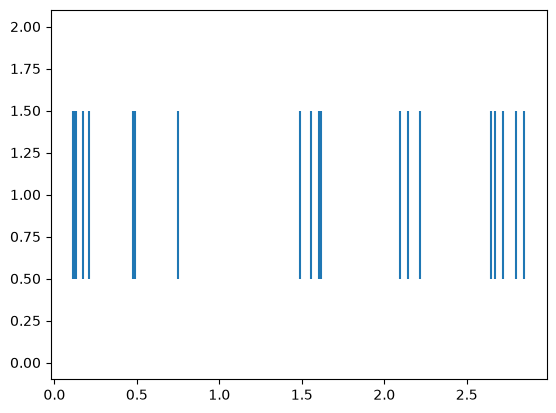

In [262]:
process = StationaryPoissonProcess(rate=5*pq.Hz, t_stop=3 * pq.s)
st = process.generate_spiketrain()
plt.eventplot(st.times);

**Exercise**: Use the `StationaryPoissonProcess` class to generate a spike train with an average firing rate of `8 Hz` and ending at `4 seconds` of measurement time.  Display a raster plot of the generated spike times.

**Exercise**: Instead of generating a single spike train with `proces.generate_spiketrain()`, use `process.generate_n_spiketrains(as_array=True)` to generate `50` spike trains' times, then display them as a raster plot.

## Section 4: Working With Physical Quantities

Neuroscience data almost always come with physical units: time might be measured in seconds or milliseconds, firing rate in Hertz, and voltage in volts or millivolts. It is easy to make mistakes when these units are tracked only in variable names or comments. The quantities package helps by attaching units directly to values. This means Python can convert compatible units automatically and raise an error when you try to combine quantities that do not make physical sense. In this section, you will practice creating unit-aware variables, inspecting their units and magnitudes, and using them to compute quantities such as expected spike count.

### Code Reference

| Code | Description |
| --- | --- |
| `freq = 2 * pq.Hz` | Define a quantity of 2 Hertz and assign it to the variable `freq` |
| `time = 2500 * pq.ms` | Define a quantity of 2500 milliseconds and assign it to the variable `time` |
| `time.units` | Get the unit of `time` |
| `time.magnitude` | Get the magnitude of `time` |

### Exercises

**Example**: Create  a variable called `firing_rate` and assign it the value `5 * pq.Hz`.

In [ ]:
firing_rate = 5 * pq.Hz

**Exercise**: Create  a variable called `t_start` and assign it the value `100*pq.ms`.

**Exercise**: Create  a variable called `t_stop` and assign it the value `3 * pq.s`

**Exercise**: Compute the difference between `t_stop` and `t_start` and assign the result to a new variable `duration`. Then, print that variable.

**Exercise**: Get the `.magnitude` and the `.units` of `duration`.

**Exercise**: Try adding the variables `firing_rate` and `duration`. What error message do you observe?

**Exercise**: Multiply `firing_rate` by `duration` and assign the result to a new variable `n_spikes`. Print that variable.